In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [7]:
df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\house_prices_practice.csv")

In [8]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [10]:
print("EXPLORE DATA SET")

EXPLORE DATA SET


In [ ]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(300, 10)


In [12]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB
None


In [13]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [14]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               Id  OverallQual    GrLivArea  GarageCars  TotalBsmtSF  \
count  300.000000   300.000000   300.000000  300.000000   300.000000   
mean   150.500000     5.326667  2307.386667    1.330000  1468.796667   
std     86.746758     2.873001  1042.561303    1.109898   672.333705   
min      1.000000     1.000000   504.000000    0.000000   303.000000   
25%     75.750000     3.000000  1392.250000    0.000000   903.000000   
50%    150.500000     5.000000  2265.500000    1.000000  1502.000000   
75%    225.250000     8.000000  3306.500000    2.000000  2129.500000   
max    300.000000    10.000000  3998.000000    3.000000  2492.000000   

         YearBuilt    FullBath  BedroomAbvGr       LotArea      SalePrice  
count   300.000000  300.000000    300.000000    300.000000     300.000000  
mean   1986.163333    1.523333      2.926667   8969.453333  252262.903333  
std      21.377089    1.131543      1.456604   3753.531132   74998.055214  
min    1950.000000    0.0

In [17]:
print("Data Cleaning and Preprocessing")


Data Cleaning and Preprocessing


In [18]:
# Fill missing numerical values with mean
numeric_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [19]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [20]:
print("Feature Selection ")

Feature Selection 


In [23]:
target_column = 'SalePrice'
# Features (X) and Target (y)
X = df.drop(columns=[target_column])
y = df[target_column]
# Convert categorical columns into dummy variables
X = pd.get_dummies(X, drop_first=True)
print("\nFeature Columns:")
print(X.columns)


Feature Columns:
Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea'],
      dtype='str')


In [24]:
print(" train data set")
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

 train data set

Training Data Shape: (240, 9)
Testing Data Shape: (60, 9)


In [25]:
print("train Linear regression model")
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel Training Completed")

train Linear regression model

Model Training Completed


In [26]:
print("Price prediction on test data")
y_pred = model.predict(X_test)
print("\nSample Predictions:")
pred_df = pd.DataFrame({ 'Actual Price': y_test.values, 'Predicted Price': y_pred})
print(pred_df.head())

Price prediction on test data

Sample Predictions:
   Actual Price  Predicted Price
0      224163.0    239161.991995
1      203881.0    190490.822096
2      380236.0    398000.832854
3      211664.0    223167.956280
4      122139.0    135189.103513


In [27]:
print("Model Evaluation Metrics using RMSE and R-squared (R2 Score)")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation")
print("RMSE:", rmse)
print("R-squared (R2 Score):", r2)


Model Evaluation Metrics using RMSE and R-squared (R2 Score)

Model Evaluation
RMSE: 12505.534960423414
R-squared (R2 Score): 0.9724366615461925


In [28]:
print("Interpreting Model Coefficients")
coefficients = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_})
print("\nModel Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

Interpreting Model Coefficients

Model Coefficients:
        Feature   Coefficient
3    GarageCars  19109.616189
1   OverallQual  11914.730009
6      FullBath  11040.318386
7  BedroomAbvGr   4812.064348
5     YearBuilt    746.368096
2     GrLivArea     55.410245
4   TotalBsmtSF     25.199107
0            Id      0.011021
8       LotArea     -0.159507


Visualizing Actual vs Predicted Prices


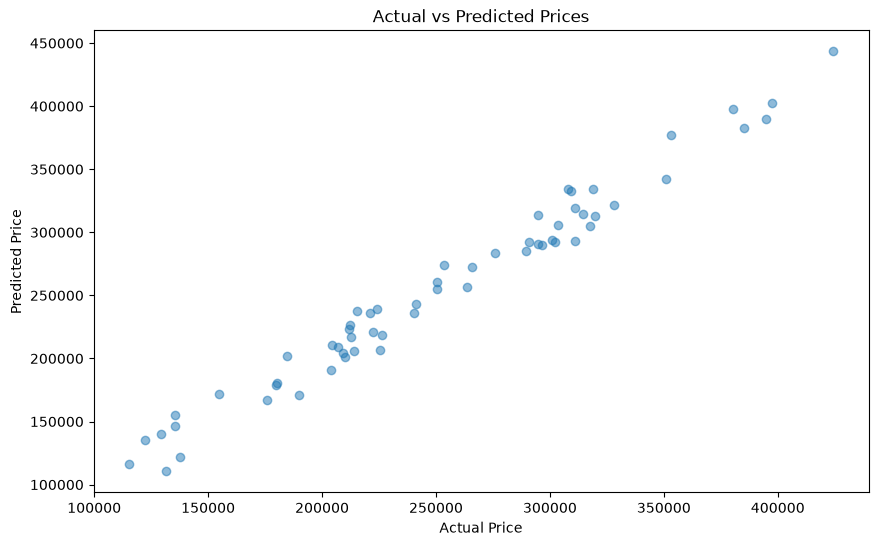

In [30]:
print("Visualizing Actual vs Predicted Prices")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [35]:
example = X_test.iloc[0:1]
example_prediction = model.predict(example)
print("\nExample Prediction:")
print("Predicted House Price:", example_prediction[0])
print("\nActual House Price:", y_test.iloc[0])


Example Prediction:
Predicted House Price: 239161.99199450784

Actual House Price: 224163.0


In [ ]:

joblib.dump(model, "linear_regression_house_price_model.pkl")

print("\nModel saved successfully as:")
print("linear_regression_house_price_model.pkl")

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

correalation matrix and heatmap

Correlation Matrix:
                    Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  \
Id            1.000000    -0.158700   0.050807   -0.008250    -0.024281   
OverallQual  -0.158700     1.000000  -0.116413   -0.017138     0.008098   
GrLivArea     0.050807    -0.116413   1.000000    0.056380     0.023471   
GarageCars   -0.008250    -0.017138   0.056380    1.000000     0.051605   
TotalBsmtSF  -0.024281     0.008098   0.023471    0.051605     1.000000   
YearBuilt     0.037105     0.005990   0.032073   -0.031599    -0.050187   
FullBath      0.064142    -0.047619   0.103215    0.125668     0.042792   
BedroomAbvGr -0.006326    -0.056594  -0.090480    0.083287    -0.039197   
LotArea      -0.060973    -0.030605  -0.035433   -0.005316    -0.007753   
SalePrice    -0.025416     0.352899   0.745095    0.351321     0.250178   

              YearBuilt  FullBath  BedroomAbvGr   LotArea  SalePrice  
Id             0.037105  0.064142     -0.006326 -0

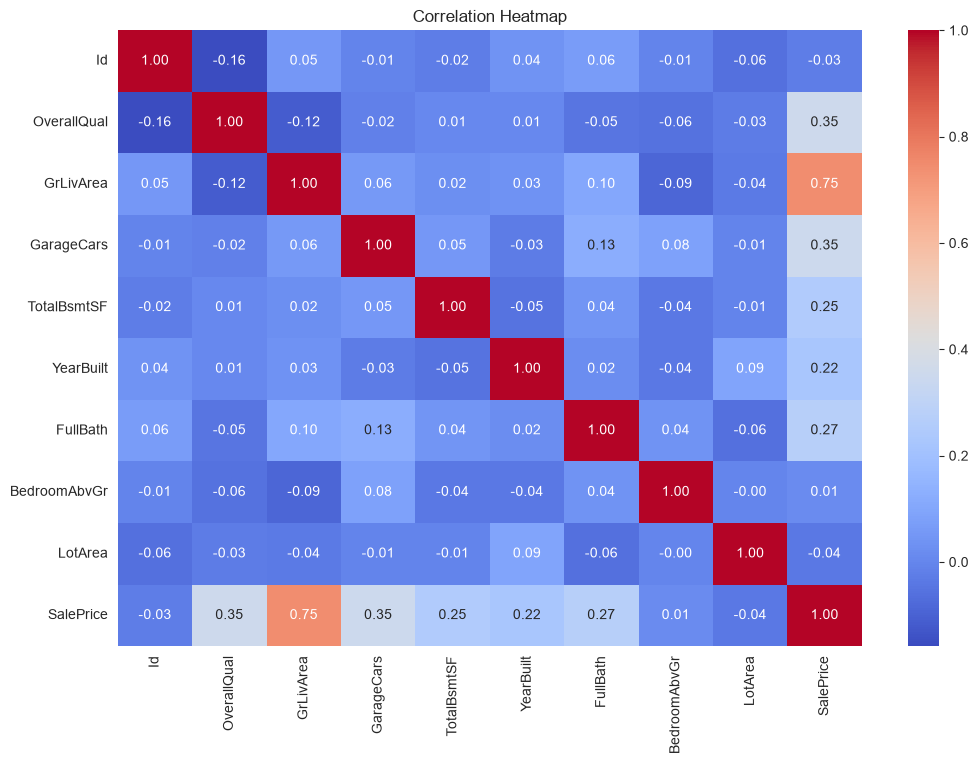

In [38]:
print("correalation matrix and heatmap")
# Set figure style
sns.set_style("whitegrid")
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# Correlation matrix
corr_matrix = numeric_df.corr()
print("\nCorrelation Matrix:")
print(corr_matrix)
print("Heatmap of Correlation Matrix:")
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


Histogram for Numerical Features


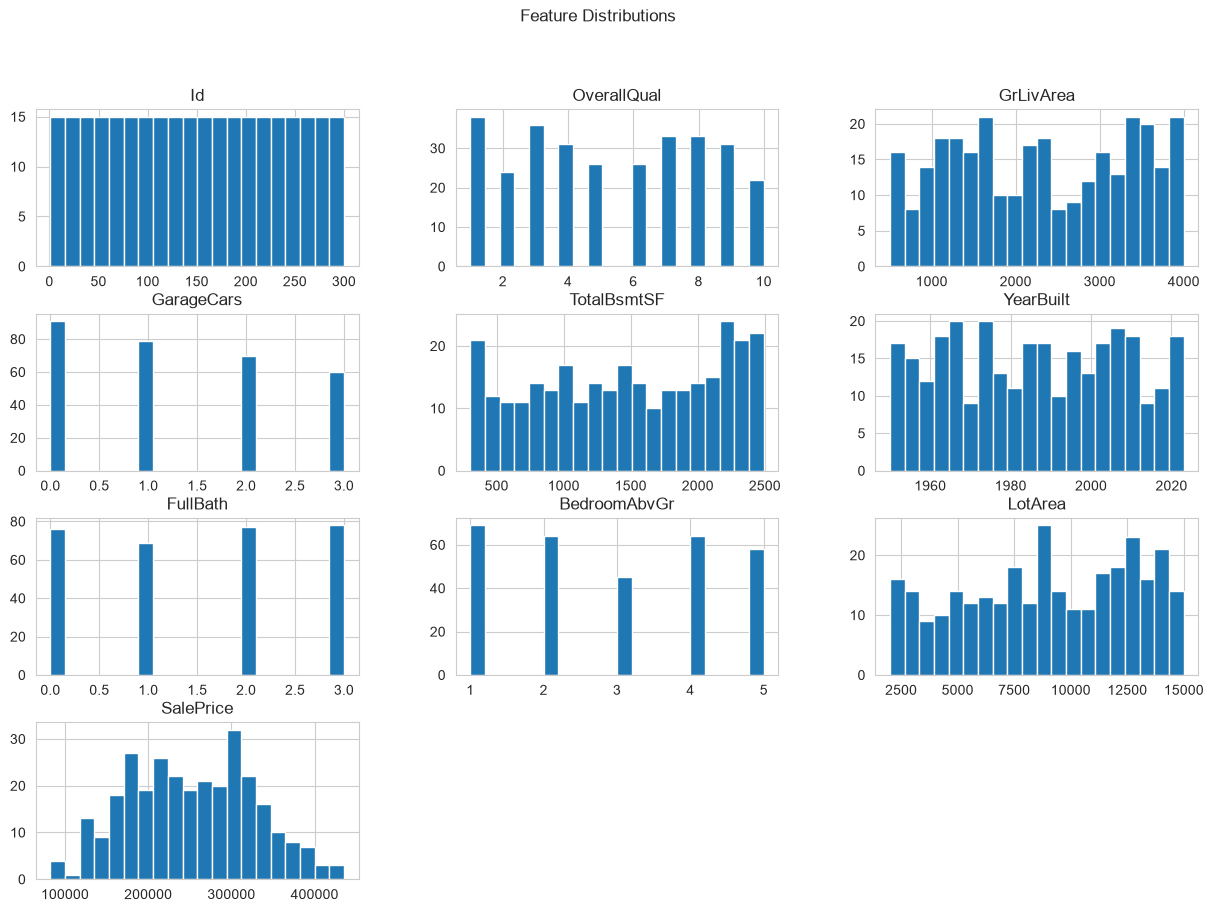

In [39]:
print("Histogram for Numerical Features")
numeric_df.hist(figsize=(15,10),bins=20)
plt.suptitle("Feature Distributions")
plt.show()


Pairplot for Numerical Features


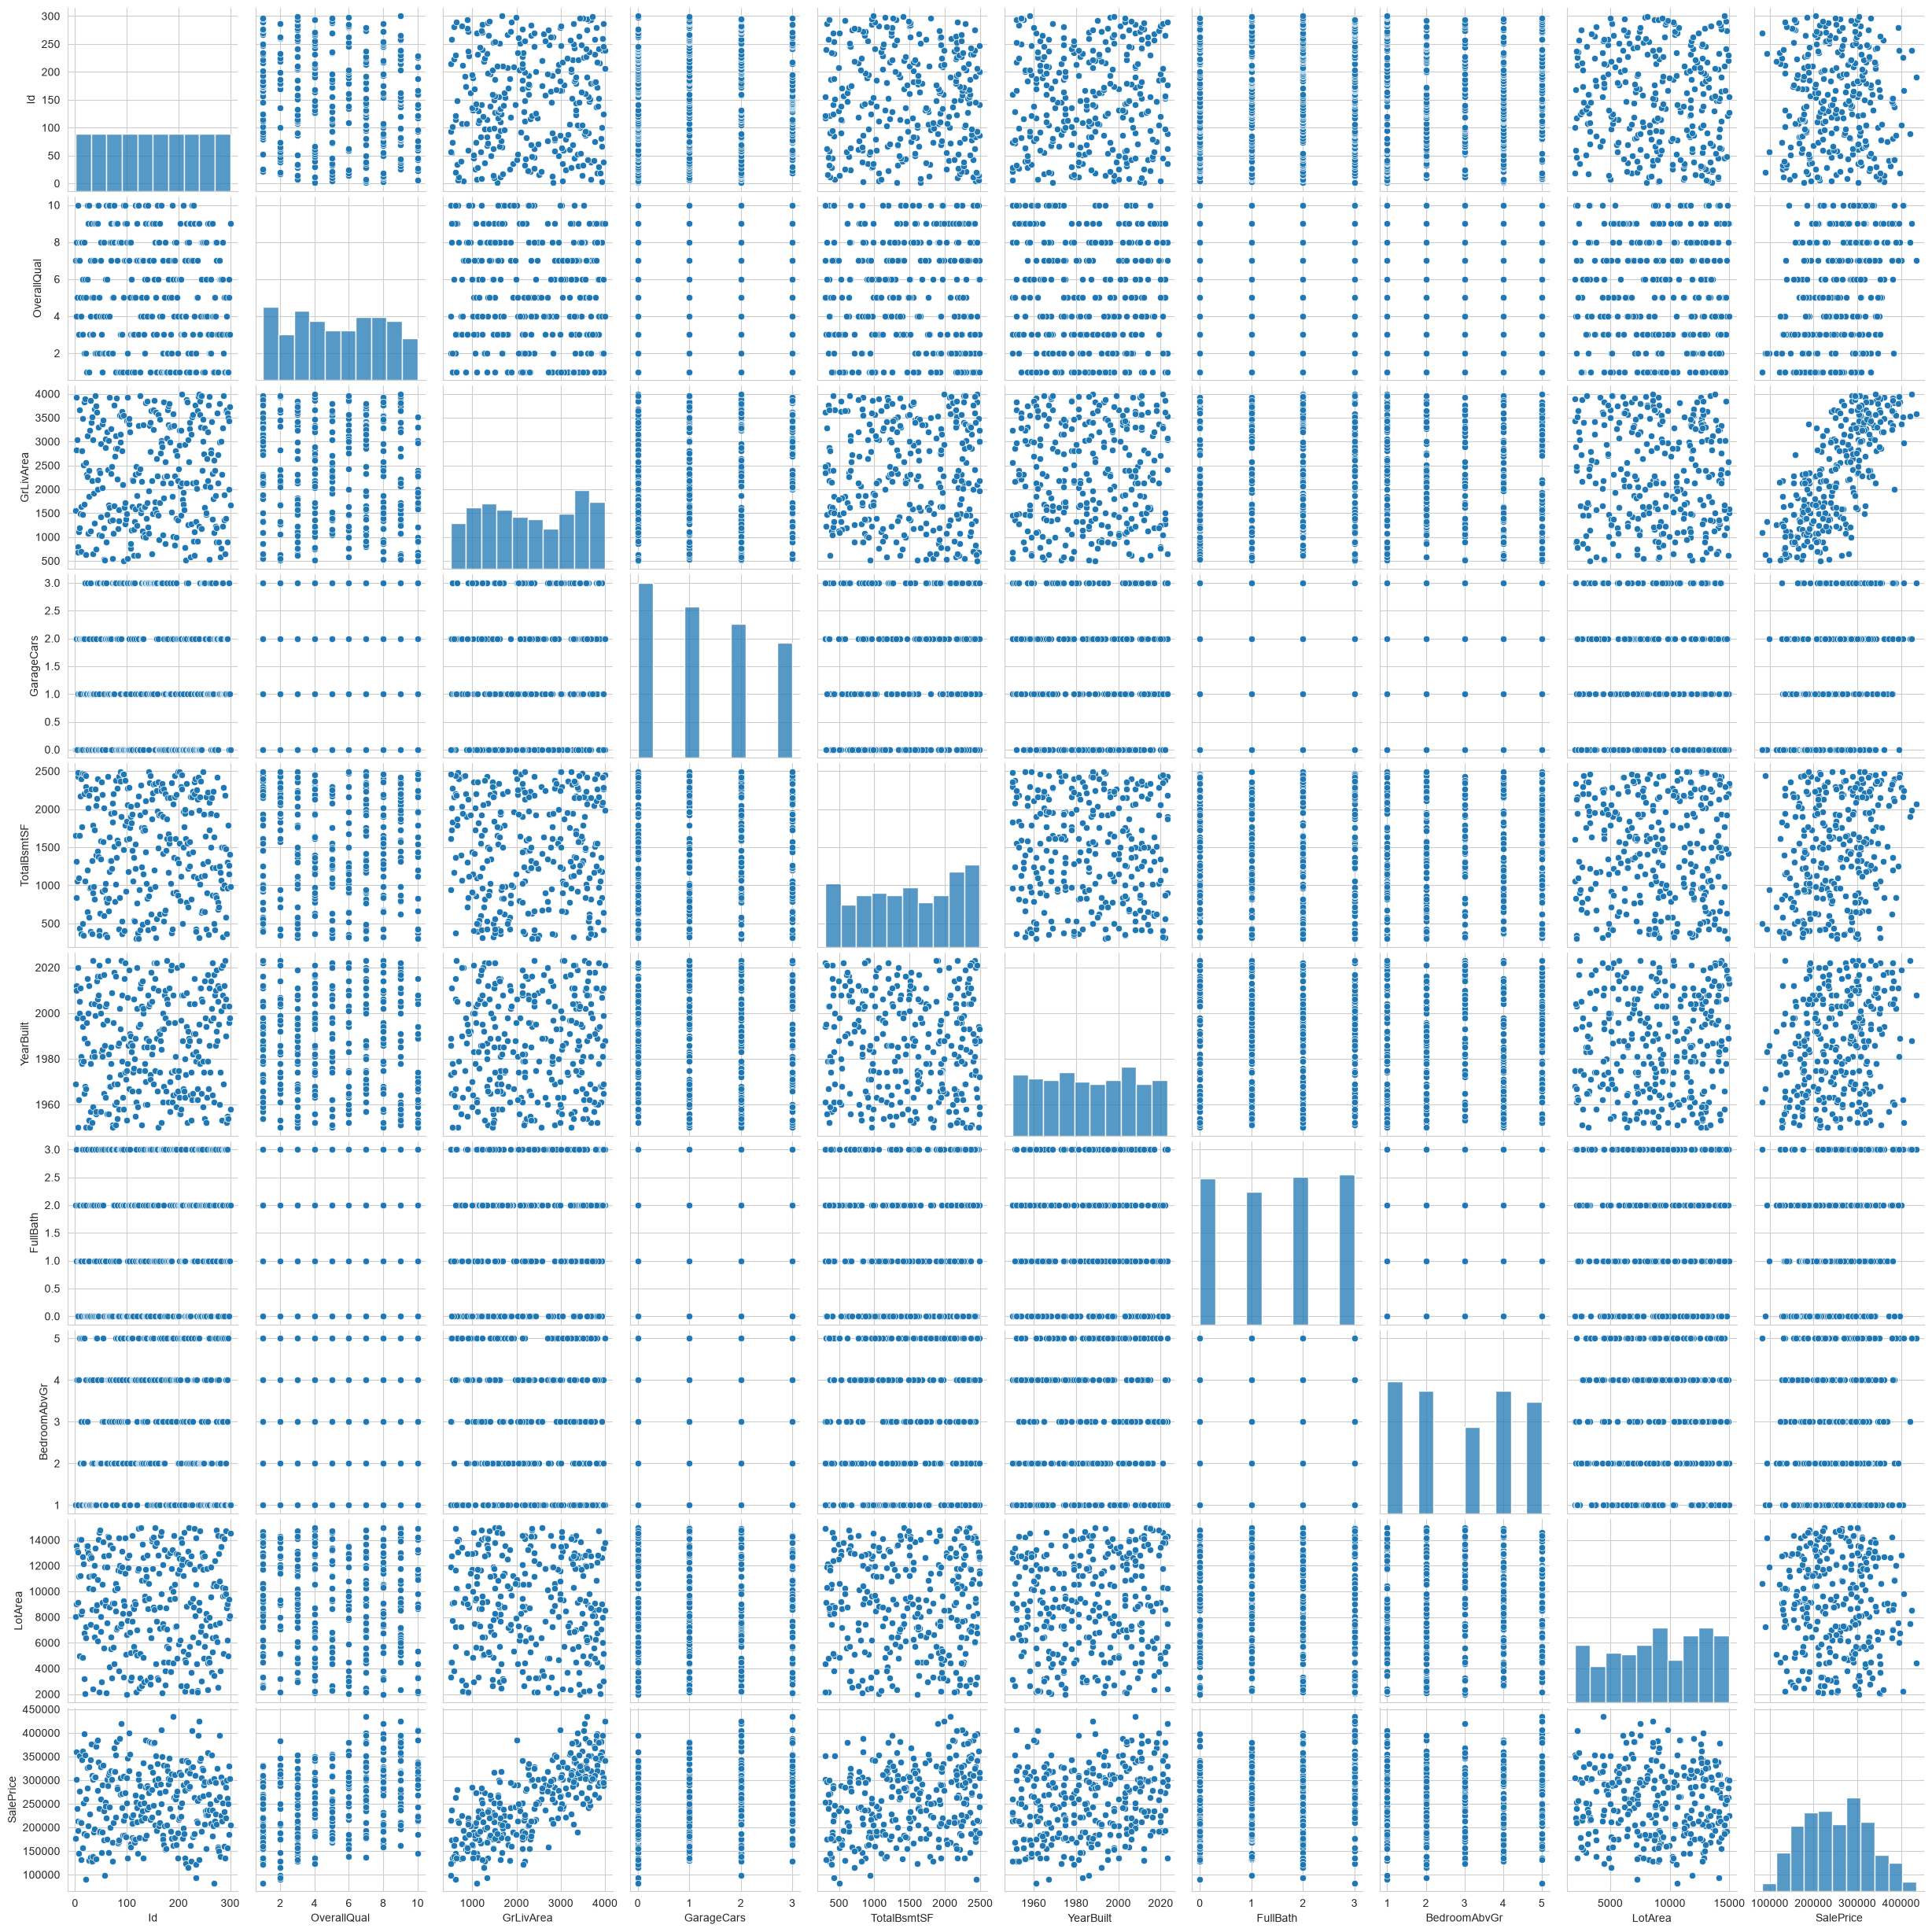

In [51]:
print("Pairplot for Numerical Features")
# Shows relationships between features
sns.pairplot(numeric_df)
plt.show()



Scatter Plot for Area vs Price
['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice']


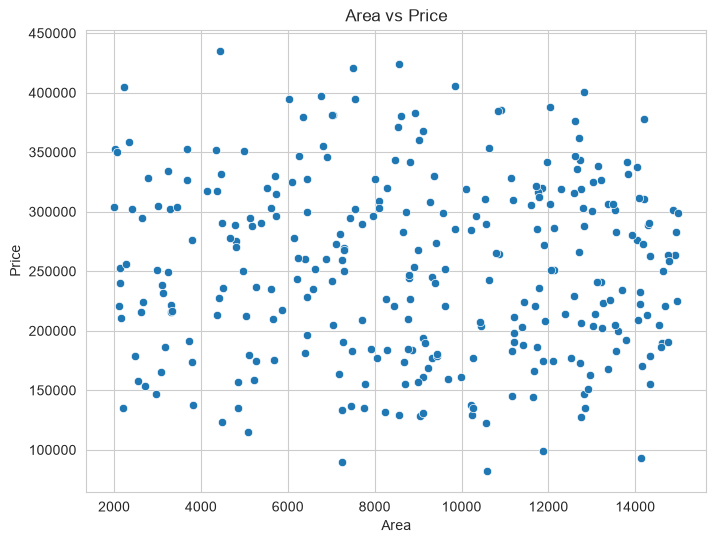

In [43]:
print("Scatter Plot for Area vs Price")
# Replace 'area' and 'price' with your column names
print(df.columns.tolist())
plt.figure(figsize=(8,6))
sns.scatterplot( x=df['LotArea'], y=df['SalePrice'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

Boxplot for Numerical Features


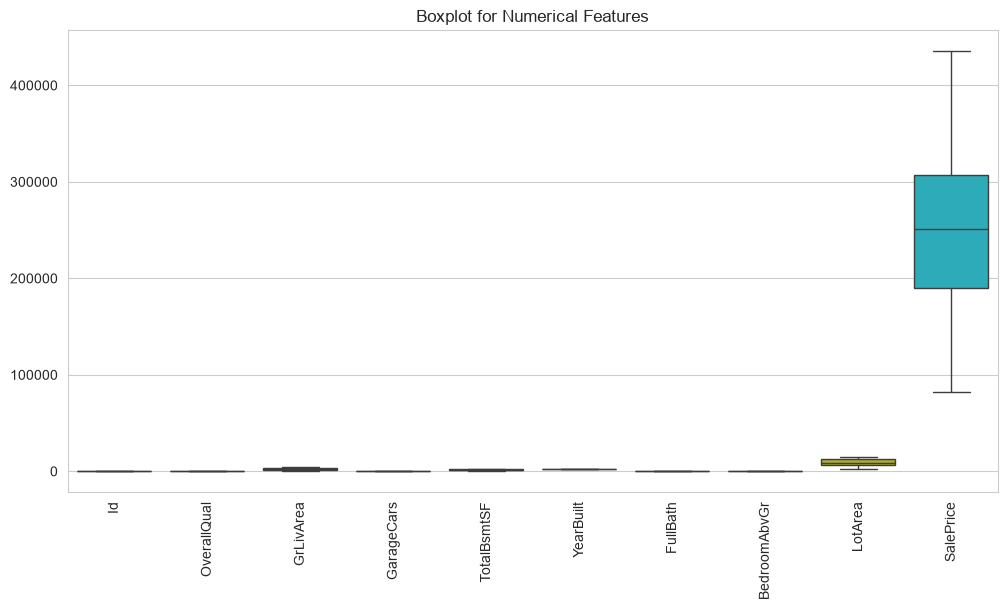

In [44]:
print("Boxplot for Numerical Features")
# Detect outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)
plt.title("Boxplot for Numerical Features")
plt.show()


Actual vs Predicted Prices


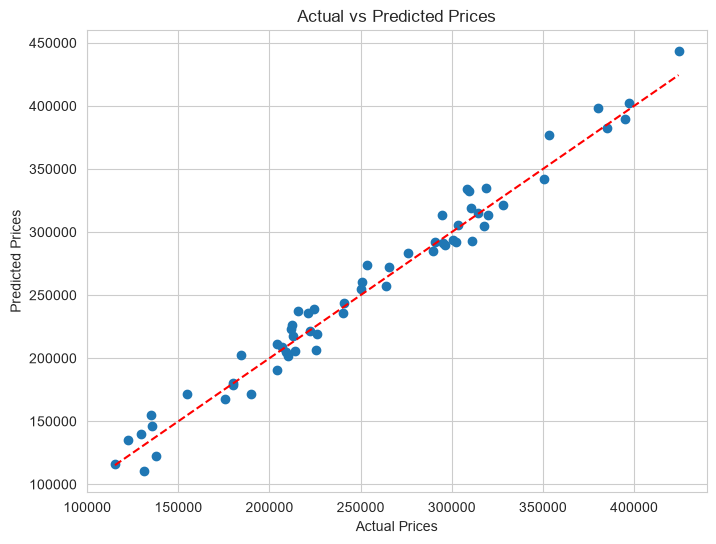

In [45]:
print("Actual vs Predicted Prices")
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()


Residual Plot


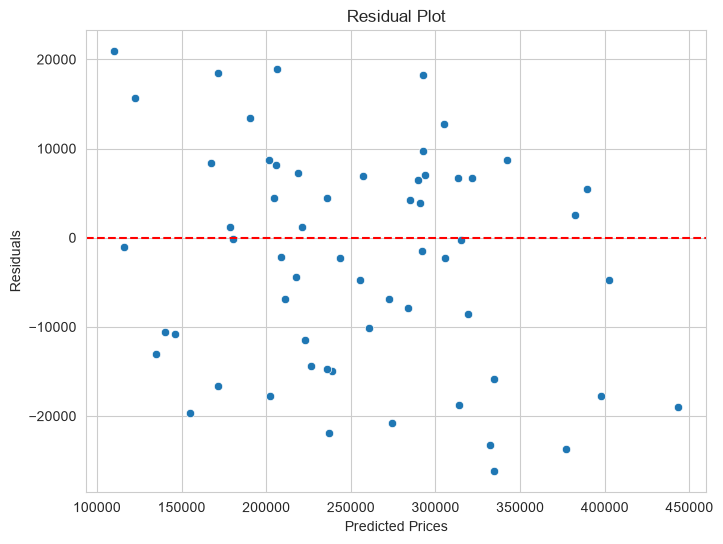

In [46]:
print("Residual Plot")
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot( x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Feature Importance based on Coefficients

Feature Importance:
        Feature   Coefficient
3    GarageCars  19109.616189
1   OverallQual  11914.730009
6      FullBath  11040.318386
7  BedroomAbvGr   4812.064348
5     YearBuilt    746.368096
2     GrLivArea     55.410245
4   TotalBsmtSF     25.199107
0            Id      0.011021
8       LotArea     -0.159507


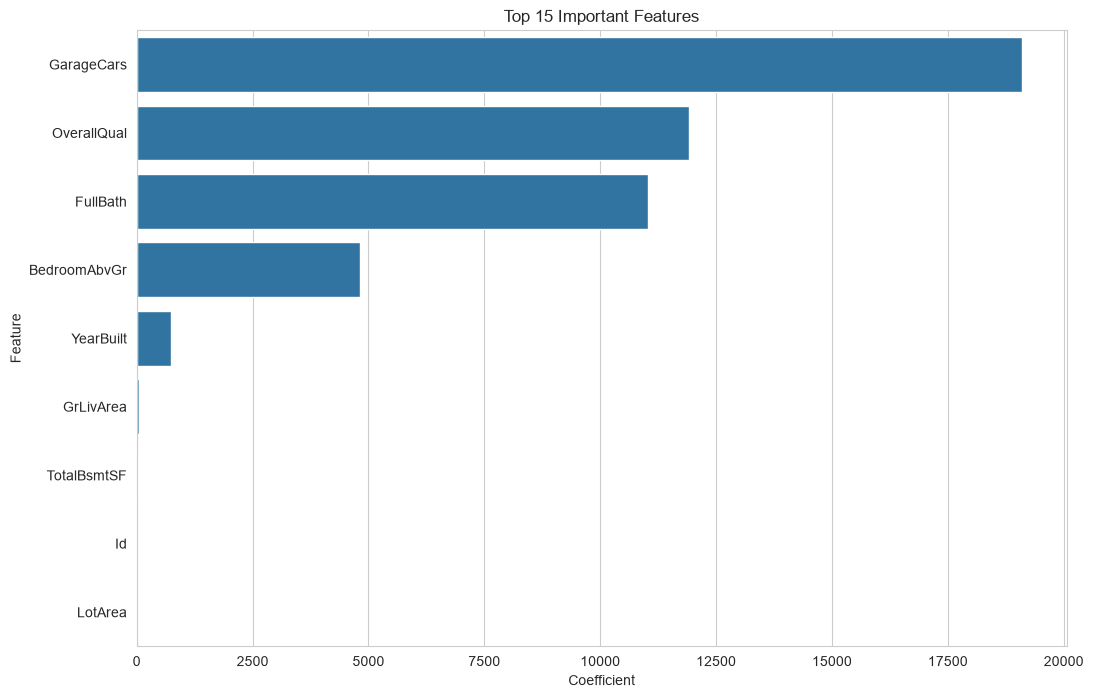

In [47]:
print("Feature Importance based on Coefficients")
coefficients = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_})

# Sort coefficients
coefficients = coefficients.sort_values(by='Coefficient',ascending=False)
print("\nFeature Importance:")
print(coefficients)

# Plot coefficients

plt.figure(figsize=(12,8))

sns.barplot(x='Coefficient',y='Feature',data=coefficients.head(15))
plt.title("Top 15 Important Features")

plt.show()